In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, binomtest, beta

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
baseline = 0.10
n = 500
k = 63

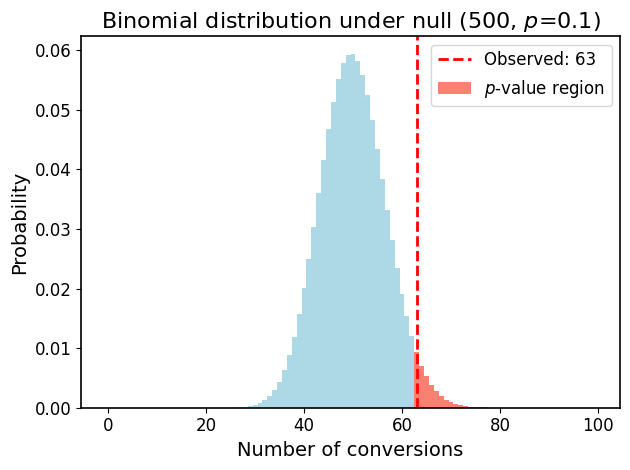

In [7]:
x = np.arange(0, 100)

# Binomial PMF
pmf = binom.pmf(x, n, baseline)

# Plot the PMF
# plt.bar(x, pmf, color='lightblue', label='Binomial PMF', width=1)
plt.bar(x, pmf, color='lightblue', width=1)

# Mark observed value
plt.axvline(k, color='red', linestyle='--', linewidth=2, label=f'Observed: {k}')

# Shade tail for p-value (P(X >= observed))
tail_x = np.arange(k, 100)
plt.bar(tail_x, pmf[k:], color='salmon', label='$p$-value region', width=1)

plt.xlabel('Number of conversions')
plt.ylabel('Probability')
plt.title(f'Binomial distribution under null ({n}, $p$={baseline})')
plt.legend()
plt.tight_layout()
plt.show()

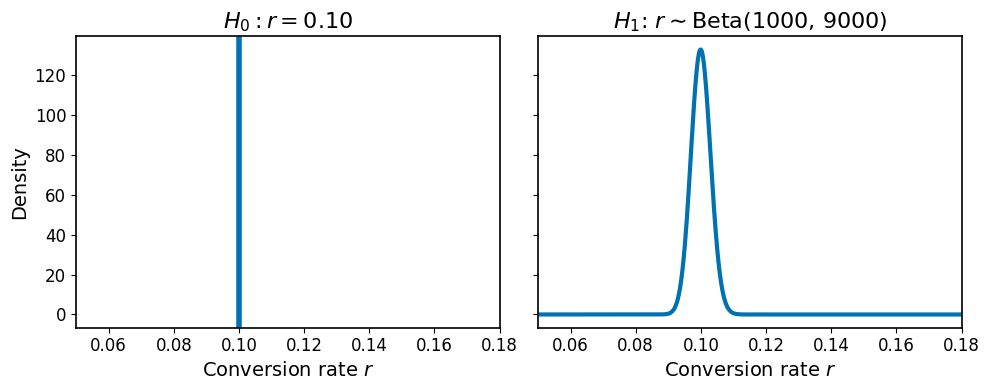

In [6]:
# Data
n = 500
successes = 63
failures = n - successes

# Prior Beta(1,1)
a_prior = 1000
b_prior = 9000

# Posterior parameters
a_post = 1000
b_post = 9000

# Grid for p
p = np.linspace(0.05, 0.18, 1000)

# Posterior density
posterior = beta.pdf(p, a_post, b_post)

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# --- H0 subplot ---
axes[0].axvline(0.1, linewidth=4)
axes[0].set_title(r"$H_0: r = 0.10$")
axes[0].set_xlabel("Conversion rate $r$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0.05, 0.18)

# observed rate
# axes[0].axvline(successes/n, linestyle="--")

# --- H1 subplot ---
axes[1].plot(p, posterior, linewidth=3)
axes[1].set_title(r"$H_1$: $r \sim$Beta(" + str(a_post) + ", " + str(b_post) + ")")
axes[1].set_xlabel("Conversion rate $r$")
axes[1].set_xlim(0.05, 0.18)
# axes[1].set_ylim(0, 2)

# observed rate
# axes[1].axvline(successes/n, linestyle="--")

plt.tight_layout()
plt.show()